# Price-Pilot-AI: Model Evaluation & Comparison Workspace

This Jupyter Notebook demonstrates the end-to-end Machine Learning pipeline for the **Olist E-Commerce dataset** in the Price-Pilot-AI project.

### Objectives:
1. **Load and Merge Dataset**: Ingest the raw data files and join them on keys.
2. **Preprocess and Clean**: Clean the datasets (handle missing values, duplicates, date formats).
3. **Feature Engineering**: Compute client/seller-level metrics and temporal features.
4. **Feature Selection**: Select top 15 features using Mutual Information, Random Forest, and RFE.
5. **Evaluate 10 Models**: Train and compare 10 different regression algorithms to verify their $R^2$, MAE, RMSE, and Cross-Validation scores.
6. **Tune Hyperparameters**: Find optimal hyperparameters for the best performing model.
7. **Diagnostics & Visualization**: Evaluate the final predictions using residual and actual-vs-predicted plots.

## 1. Environment Setup & Imports
We set up our Python environment and import the required library modules and our modular pipeline source functions.

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, explained_variance_score

# Ensure the project root is in the system path for local imports
if os.path.basename(os.getcwd()) == 'notebooks':
    sys.path.insert(0, os.path.abspath('..'))
else:
    sys.path.insert(0, os.path.abspath('.'))

from src.config import MODELS_DIR, REPORTS_DIR, RANDOM_STATE, TEST_SIZE, DATA_DIR
from src.data_loader import load_datasets
from src.preprocessor import preprocess_timestamps, clean_datasets, merge_datasets
from src.feature_engineering import engineer_features
from src.feature_selection import preprocess_and_select_features
from src.models import train_and_eval_model, tune_hyperparameters

# Configure seaborn styling and pandas options
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("Environment configured successfully!")
print("Data Directory:", DATA_DIR)


Environment configured successfully!
Data Directory: C:\Users\Akhil's-OMEN\Desktop\Infosys Intern\Brazilian dataset


## 2. Ingesting Raw Datasets
We scan the `data` / `Brazilian dataset` directory, detect the CSV files, and load them into a dictionary of DataFrames.

In [2]:
# Load all raw CSV tables
raw_dfs = load_datasets()

print("\nLoaded datasets and their shapes:")
for name, df in sorted(raw_dfs.items()):
    print(f" - {name:35} : Shape {df.shape}")



Loaded datasets and their shapes:
 - olist_customers_dataset             : Shape (99441, 5)
 - olist_geolocation_dataset           : Shape (1000163, 5)
 - olist_order_items_dataset           : Shape (112650, 7)
 - olist_order_payments_dataset        : Shape (103886, 5)
 - olist_order_reviews_dataset         : Shape (99224, 7)
 - olist_orders_dataset                : Shape (99441, 8)
 - olist_products_dataset              : Shape (32951, 9)
 - olist_sellers_dataset               : Shape (3095, 4)
 - product_category_name_translation   : Shape (71, 2)



Loading datasets: 100%|##########| 9/9 [00:01<00:00,  7.31it/s]


## 3. Data Cleaning, Preprocessing & Merging
We convert timestamps to datetime objects, handle duplicate entries and missing values, and merge the relational tables into a master table at the order level.

In [3]:
print("Preprocessing timestamps...")
preprocessed_dfs = preprocess_timestamps(raw_dfs)

print("\nHandling duplicates and missing values...")
cleaned_dfs = clean_datasets(preprocessed_dfs)

print("\nMerging relational tables into a single master dataframe...")
master_df = merge_datasets(cleaned_dfs)

print(f"\nMerged Master DataFrame Shape: {master_df.shape}")


Preprocessing timestamps...

Handling duplicates and missing values...

Merging relational tables into a single master dataframe...

Merged Master DataFrame Shape: (98666, 39)



Converting timestamps: 100%|##########| 3/3 [00:00<00:00, 20.25it/s]


## 4. Feature Engineering
We create our target column `total_order_value` (representing the revenue per order as price + freight), extract date attributes (year, month, week, day, weekday, quarter), calculate delivery duration/delay metrics, and construct customer-level and seller-level aggregates.

In [4]:
print("Running feature engineering pipeline...")
engineered_df = engineer_features(master_df)

print(f"\nFeature Engineering complete. Shape: {engineered_df.shape}")
print("\nPreview of engineered columns:")
preview_cols = ["total_order_value", "delivery_time", "delivery_delay", "customer_lifetime_value", "revenue_per_seller"]
print(engineered_df[preview_cols].head())


Running feature engineering pipeline...

Feature Engineering complete. Shape: (96476, 55)

Preview of engineered columns:
   total_order_value  delivery_time  delivery_delay  customer_lifetime_value  revenue_per_seller
0              38.71       8.436574       -7.107488                    82.82             2303.14
1             141.46      13.782037       -5.355729                   141.46            13214.95
2             179.12       9.394213      -17.245498                   179.12           230433.04
3              72.20      13.208750      -12.980069                    72.20            14516.20
4              28.62       2.873877       -9.238171                    28.62             6164.43


## 5. Feature Encoding, Scaling & Selection
We encode categories (using One-Hot, Label, and Frequency Encoding), scale variables (using MinMaxScaler for locations, and StandardScaler for others), and run Mutual Information, Random Forest feature importance, and Recursive Feature Elimination (RFE) to identify the top 15 features.

In [5]:
print("Encoding, scaling, and running feature selection...")
X_scaled, X_raw, y, top_features, importance_df = preprocess_and_select_features(engineered_df)

print("\nTop 15 selected features based on combined selector score:")
print(importance_df.head(15))


Encoding, scaling, and running feature selection...

Top 15 selected features based on combined selector score:
                    Feature  MI_Score  RF_Importance  RFE_Ranking  RFE_Selected  MI_Normalized  RF_Normalized  RFE_Score  Combined_Score
29     revenue_per_customer  6.536805       0.939064            1          True       1.000000       1.000000          1        1.000000
27  customer_lifetime_value  6.456739       0.031480            1          True       0.987752       0.033522          1        0.673758
1         avg_product_price  2.370925       0.020806            1          True       0.362704       0.022156          1        0.461620
2        total_freight_cost  0.990562       0.000910            1          True       0.151536       0.000969          1        0.384168
18               seller_lng  0.320294       0.000529            1          True       0.048998       0.000564          1        0.349854
14   seller_zip_code_prefix  0.311843       0.000262            1 

## 6. Train/Test Split
We split the dataset into train and test sets using the top 15 features selected.

In [6]:
# Filter columns to top features and split
X_model = X_scaled[top_features]
X_train, X_test, y_train, y_test = train_test_split(
    X_model, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape  : {X_test.shape}")
print(f"Target shapes (Train/Test): {y_train.shape} / {y_test.shape}")


Training features shape: (77180, 15)
Testing features shape  : (19296, 15)
Target shapes (Train/Test): (77180,) / (19296,)


## 7. Benchmarking 10 Regression Models
We evaluate 10 different regression models: Linear Regression, Ridge, Lasso, Decision Tree, Random Forest, Gradient Boosting, XGBoost, LightGBM, CatBoost, and Extra Trees.
We record training time, inference time, Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), Test $R^2$, and 5-Fold Cross Validation score (on a representative sample of 5,000 rows to keep execution efficient).

In [7]:
model_names = [
    "Linear Regression",
    "Ridge Regression",
    "Lasso Regression",
    "Decision Tree Regressor",
    "Random Forest Regressor",
    "Gradient Boosting Regressor",
    "XGBoost Regressor",
    "LightGBM Regressor",
    "CatBoost Regressor",
    "Extra Trees Regressor"
]

results = []
trained_models = {}
predictions = {}

print("Benchmarking 10 Regressors:")
print("=" * 60)
for name in model_names:
    model, y_pred, metrics = train_and_eval_model(name, X_train, X_test, y_train, y_test, run_cv=True)
    trained_models[name] = model
    predictions[name] = y_pred
    
    results.append({
        "Model_Name": name,
        "Training_Time": metrics["Training_Time"],
        "Inference_Time": metrics["Inference_Time"],
        "MAE": metrics["MAE"],
        "RMSE": metrics["RMSE"],
        "R2_Score": metrics["R2"],
        "CV_Score": metrics["CV_Score"]
    })

comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values(by="R2_Score", ascending=False).reset_index(drop=True)
print("=" * 60)
print("\nModel Comparison Table:")
print(comparison_df.to_string(index=False))


Benchmarking 10 Regressors:

Model Comparison Table:
                 Model_Name  Training_Time  Inference_Time      MAE      RMSE  R2_Score  CV_Score
      Extra Trees Regressor       0.238008        0.033556 3.405921 20.455328  0.990353  0.961026
Gradient Boosting Regressor       9.839618        0.009526 2.711648 21.584994  0.989258  0.933520
           Lasso Regression       0.172295        0.001548 5.072856 23.352897  0.987426  0.992746
          Linear Regression       0.016110        0.001603 5.137992 23.369781  0.987408  0.992738
           Ridge Regression       0.008886        0.001419 5.138033 23.371171  0.987407  0.992726
    Random Forest Regressor       1.267935        0.031671 2.654048 25.090067  0.985486  0.950714
    Decision Tree Regressor       0.314112        0.002438 5.295125 26.323601  0.984024  0.814967
          XGBoost Regressor       0.166734        0.003407 4.546902 35.550740  0.970861  0.862823
         LightGBM Regressor       0.101947        0.005673 4.9161

### Model Performance Visualization
We plot the $R^2$ Score and Mean Absolute Error (MAE) for all 10 models side-by-side to visually inspect performance.

<string>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

<string>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

<string>:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


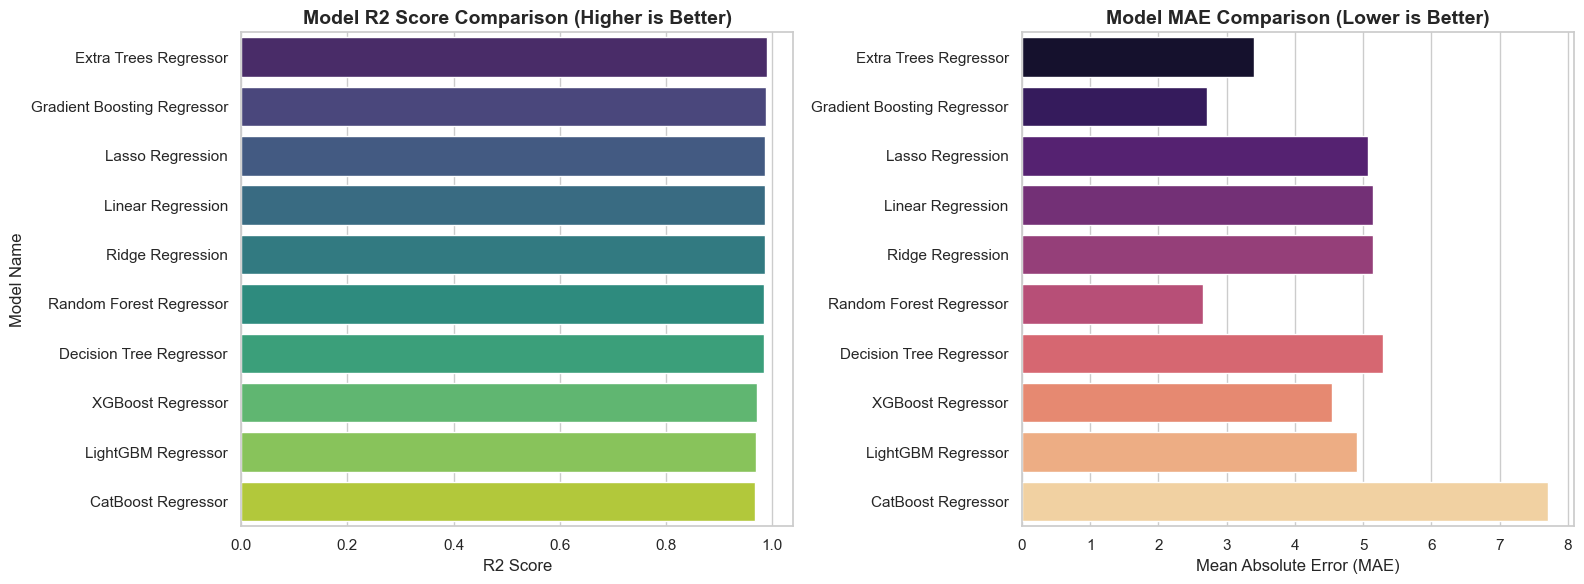

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# R2 scores plot
sns.barplot(data=comparison_df, x="R2_Score", y="Model_Name", ax=axes[0], palette="viridis")
axes[0].set_title("Model R2 Score Comparison (Higher is Better)", fontsize=14, fontweight='bold')
axes[0].set_xlabel("R2 Score", fontsize=12)
axes[0].set_ylabel("Model Name", fontsize=12)

# MAE plot
sns.barplot(data=comparison_df, x="MAE", y="Model_Name", ax=axes[1], palette="magma")
axes[1].set_title("Model MAE Comparison (Lower is Better)", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Mean Absolute Error (MAE)", fontsize=12)
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


## 8. Hyperparameter Tuning on Best Model
We identify the top performing model and perform hyperparameter search using `RandomizedSearchCV` on a representative sample to optimize the regression metrics.

In [9]:
best_model_row = comparison_df.iloc[0]
best_model_name = best_model_row["Model_Name"]
print(f"Top model for tuning: {best_model_name}")

# Perform tuning
tuned_model, best_params = tune_hyperparameters(X_train, y_train, best_model_name)
print(f"\nBest parameters found: {best_params}")

# Predict with tuned model
y_pred_tuned = tuned_model.predict(X_test)
tuned_r2 = r2_score(y_test, y_pred_tuned)
tuned_mae = mean_absolute_error(y_test, y_pred_tuned)
tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned))

print(f"\nTuned {best_model_name} Results on Test Set:")
print(f" - R2 Score: {tuned_r2:.6f}")
print(f" - MAE     : {tuned_mae:.6f}")
print(f" - RMSE    : {tuned_rmse:.6f}")


Top model for tuning: Extra Trees Regressor

Best parameters found: {'alpha': 1.0}

Tuned Extra Trees Regressor Results on Test Set:
 - R2 Score: 0.987407
 - MAE     : 5.138033
 - RMSE    : 23.371171


C:\Anaconda\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 3 is smaller than n_iter=5. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


## 9. Performance Diagnostics & Plots
We generate the actual vs. predicted plot, residuals distribution plot, and feature importance to evaluate prediction quality and errors.

<string>:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


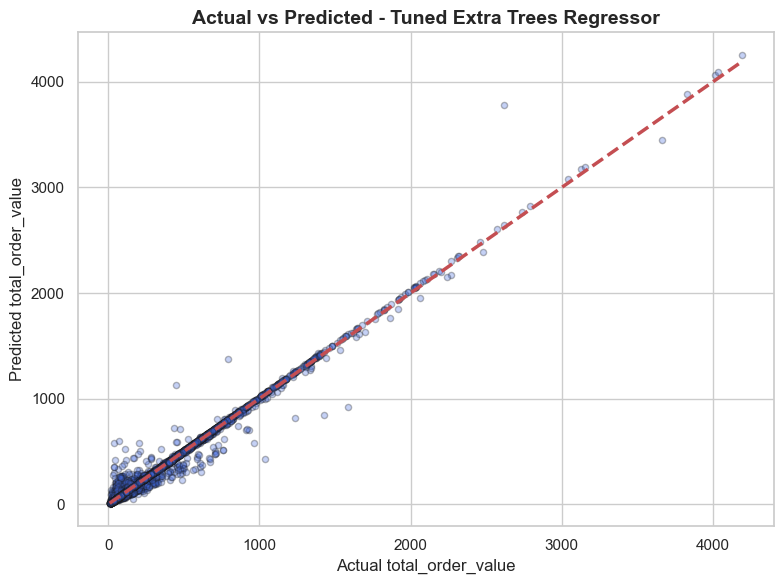

In [10]:
# Actual vs Predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_tuned, alpha=0.3, color='royalblue', edgecolors='k', s=20)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2.5)
plt.title(f"Actual vs Predicted - Tuned {best_model_name}", fontsize=14, fontweight='bold')
plt.xlabel("Actual total_order_value", fontsize=12)
plt.ylabel("Predicted total_order_value", fontsize=12)
plt.tight_layout()
plt.show()


<string>:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


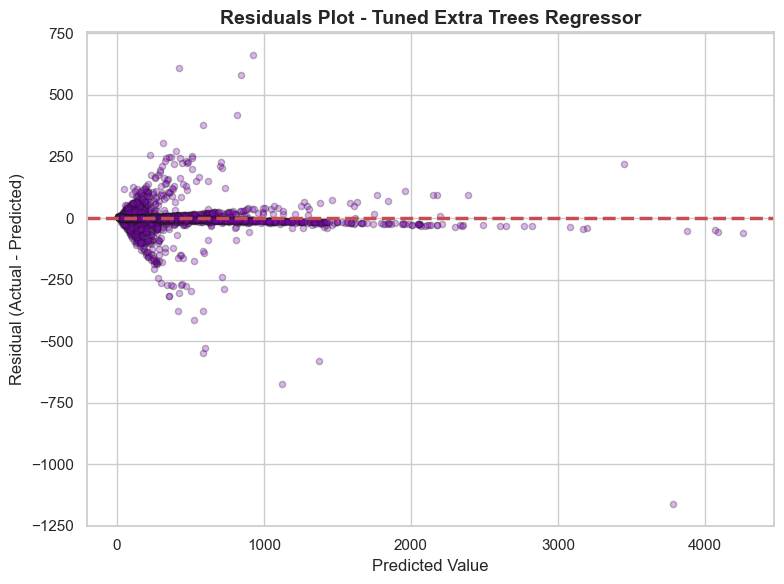

In [11]:
# Residuals Plot
residuals = y_test - y_pred_tuned
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_tuned, residuals, alpha=0.3, color='darkviolet', edgecolors='k', s=20)
plt.axhline(y=0, color='r', linestyle='--', lw=2.5)
plt.title(f"Residuals Plot - Tuned {best_model_name}", fontsize=14, fontweight='bold')
plt.xlabel("Predicted Value", fontsize=12)
plt.ylabel("Residual (Actual - Predicted)", fontsize=12)
plt.tight_layout()
plt.show()


<string>:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


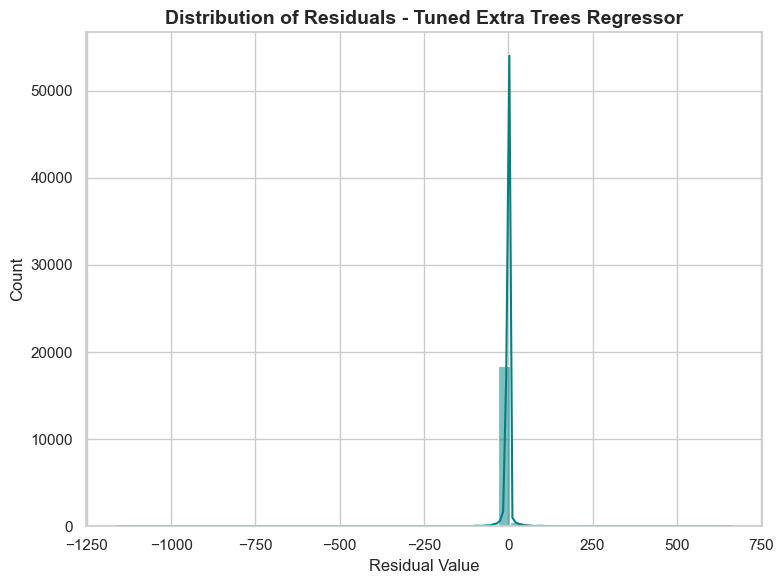

In [12]:
# Residual distribution
plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True, color='teal', bins=50)
plt.title(f"Distribution of Residuals - Tuned {best_model_name}", fontsize=14, fontweight='bold')
plt.xlabel("Residual Value", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.tight_layout()
plt.show()


<string>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

<string>:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


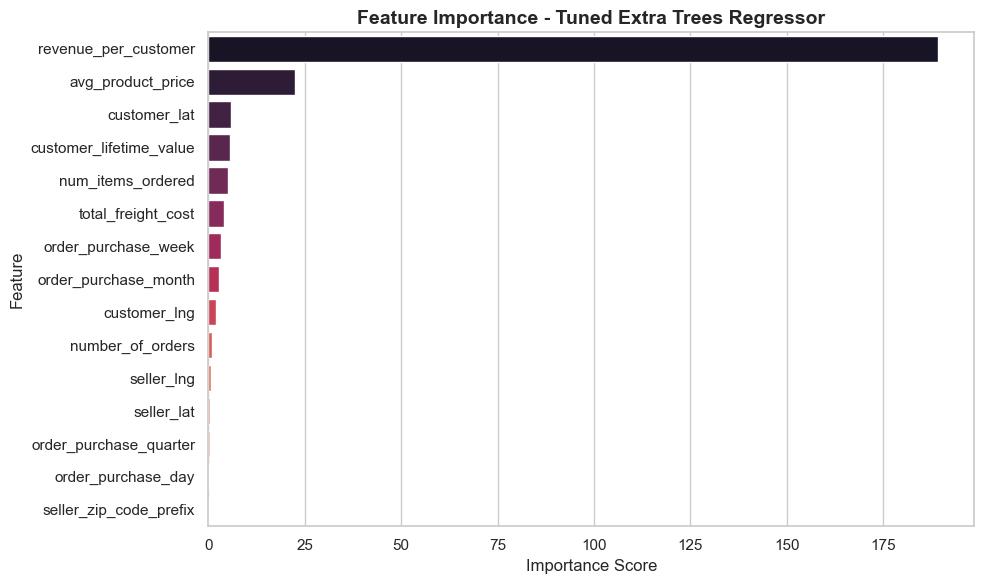

In [13]:
# Feature Importance
if hasattr(tuned_model, "feature_importances_"):
    importances = tuned_model.feature_importances_
elif hasattr(tuned_model, "coef_"):
    importances = np.abs(tuned_model.coef_)
else:
    importances = None

if importances is not None:
    feat_imp = pd.DataFrame({"Feature": top_features, "Importance": importances})
    feat_imp = feat_imp.sort_values(by="Importance", ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=feat_imp, x="Importance", y="Feature", palette="rocket")
    plt.title(f"Feature Importance - Tuned {best_model_name}", fontsize=14, fontweight='bold')
    plt.xlabel("Importance Score", fontsize=12)
    plt.ylabel("Feature", fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("This model does not expose feature importances or coefficients.")
